job prediction accuracy: 0.525
-----------------------------------
feature importance:
salary        0.267447
age           0.221749
experience    0.197887
interviews    0.173594
skills        0.139323
dtype: float64


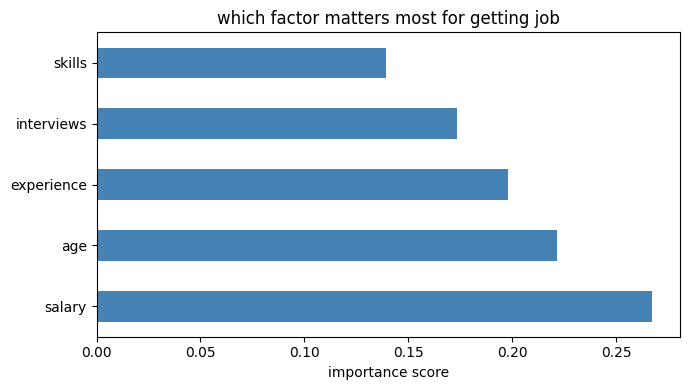

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

data = {
    "age":        np.random.randint(22, 60, n),
    "salary":     np.random.randint(20000, 150000, n),
    "experience": np.random.randint(0, 20, n),
    "skills":     np.random.randint(1, 10, n),
    "interviews": np.random.randint(1, 15, n),
    "got_job":    np.random.choice([0, 1], n, p=[0.4, 0.6])
}

df = pd.DataFrame(data)
x = df.drop("got_job", axis=1)
y = df["got_job"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

print("job prediction accuracy:", round(model.score(x_test, y_test), 3))
print("-" * 35)

importance = pd.Series(
    model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print("feature importance:")
print(importance)

plt.figure(figsize=(7, 4))
importance.plot(kind="barh", color="steelblue")
plt.title("which factor matters most for getting job")
plt.xlabel("importance score")
plt.tight_layout()
plt.show()